In [1]:
from pandas import DataFrame
from pandas import Series
from pandas import concat
from pandas import read_csv

from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from math import sqrt
from matplotlib import pyplot
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')

data = pd.read_csv("/content/drive/MyDrive/Faisal Ghazanfar /forecasting/wind_data_with_direction_class_quarter_hr_13062025.csv", encoding='unicode_escape')
df=data
df.head(5)

Mounted at /content/drive


,Produced,Expected,WindSpeed,WindDirection,Day,Hour,Week,Month,Quarter,WindDirectionClass
0,180.639,231.360,7.96,216.58,2022-10-01,0,39,10,4,S
1,261.022,284.167,8.75,216.47,2022-10-01,0,39,10,4,S
2,285.620,281.527,8.71,220.54,2022-10-01,0,39,10,4,S
3,288.249,288.787,8.82,219.82,2022-10-01,0,39,10,4,S
4,324.694,312.107,9.26,220.91,2022-10-01,0,39,10,4,S


In [2]:
from sklearn.preprocessing import LabelEncoder

df['WindDirectionClass_encoded'] = LabelEncoder().fit_transform(df['WindDirectionClass'])

In [3]:
data.describe()

,Produced,Expected,WindSpeed,WindDirection,Hour,Week,Month,Quarter,WindDirectionClass_encoded
count,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000,52560.000000
mean,106.701650,147.771538,6.539721,183.436811,11.500000,26.534247,6.526027,2.509589,4.162386
std,109.182786,123.298861,2.952275,102.415121,6.922252,15.002135,3.447884,1.116778,2.211797
min,0.000000,0.000000,0.100000,0.010000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,11.310500,33.833000,4.400000,75.320000,5.750000,14.000000,4.000000,2.000000,2.000000
50%,65.833000,114.233000,6.300000,227.315000,11.500000,27.000000,7.000000,3.000000,5.000000
75%,179.575250,278.227000,8.660000,249.730000,17.250000,39.000000,10.000000,4.000000,6.000000
max,353.400000,333.333000,19.800000,360.000000,23.000000,52.000000,12.000000,4.000000,8.000000


In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# --- 1. LOAD YOUR DATA HERE ---
# Replace 'your_data.csv' with your actual file path
df = data

# List your variables exactly as you named them
features = [
    'Produced', 'Expected', 'WindSpeed', 'WindDirection',
    'Hour', 'Week', 'Month', 'Quarter', 'WindDirectionClass_encoded'
]
target = 'Produced'

# --- 2. PREPROCESS & SCALE ---
scaler = MinMaxScaler()
# It is best to scale features and target together
scaled_data = scaler.fit_transform(df[features + [target]])

# --- 3. CREATE SLIDING WINDOWS (The 3D Shape) ---
def create_windows(data, window_size=60):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size, :-1]) # All features
        y.append(data[i + window_size, -1])    # The target
    return np.array(X), np.array(y)

# Creating the 3D arrays for the model
X_all, y_all = create_windows(scaled_data, window_size=60)

# --- 4. SPLIT INTO TRAIN AND VALIDATION ---
# For 52,560 rows, we take the first 80% for training, last 20% for validation
split_idx = int(len(X_all) * 0.8)
X_train, X_val = X_all[:split_idx], X_all[split_idx:]
y_train, y_val = y_all[:split_idx], y_all[split_idx:]



In [10]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.5 MB/s eta 0:00:00


In [11]:
!pip install optuna-integration

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 4.5 MB/s eta 0:00:00


In [13]:
import optuna
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def objective(trial):
    # --- 1. Define Search Space based on your requirements ---
    u1 = trial.suggest_int("lstm_units1", 32, 128)
    u2 = trial.suggest_int("lstm_units2", 16, 64)
    dr = trial.suggest_float("dropout", 0.1, 0.5)
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-2, log=True)
    bs = trial.suggest_categorical("batch_size", [16, 32, 64])
    eps = trial.suggest_int("epochs", 50, 200)

    # --- 2. Build the Model Architecture ---
    model = Sequential([
        # First LSTM Layer
        LSTM(u1, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
        Dropout(dr),
        # Second LSTM Layer
        LSTM(u2, return_sequences=False),
        Dropout(dr),
        Dense(1)
    ])

    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')

    # --- 3. Training with Early Stopping to save time ---
    # Stops if validation loss doesn't improve for 10 epochs
    monitor = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

    # Optuna Pruning Callback (kills bad trials mid-training)
    pruning = optuna.integration.TFKerasPruningCallback(trial, "val_loss")

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=eps,
        batch_size=bs,
        shuffle=False, # Maintain SCADA time order
        callbacks=[monitor, pruning],
        verbose=0
    )

    # Return the best validation loss achieved
    return min(history.history['val_loss'])

# --- 4. Run the Search ---
study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=30) # 30 trials is a good balance for this size

print("\n--- OPTIMIZATION COMPLETE ---")
print("Best Parameters:", study.best_params)
print("Best MSE Value:", study.best_value)

ModuleNotFoundError: No module named 'optuna'

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Neural Network Imports
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint

# --- 1. BUILD FINAL MODEL WITH YOUR BEST PARAMS ---
best = {
    'lstm_units1': 70,
    'lstm_units2': 48,
    'dropout': 0.249,
    'learning_rate': 0.00267,
    'batch_size': 64,
    'epochs': 146
}

model = Sequential([
    LSTM(best['lstm_units1'], return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(best['dropout']),
    LSTM(best['lstm_units2'], return_sequences=False),
    Dropout(best['dropout']),
    Dense(1)
])

model.compile(optimizer=Adam(learning_rate=best['learning_rate']), loss='mse')

# --- 2. COLAB SAFETY: SAVE BEST WEIGHTS DURING TRAINING ---
# This saves your work even if Colab disconnects
checkpoint = ModelCheckpoint('best_scada_model.keras', save_best_only=True, monitor='val_loss')



/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [9]:
# --- 3. FINAL TRAINING ---
print(f"Starting training on Colab for {best['epochs']} epochs...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=best['epochs'],
    batch_size=best['batch_size'],
    shuffle=False,
    callbacks=[checkpoint],
    verbose=1
)

# --- 4. PREDICTION & METRICS ---
y_pred_scaled = model.predict(X_val)

def inverse_target(scaled_val, scaler, num_features):
    dummy = np.zeros((len(scaled_val), num_features + 1))
    dummy[:, -1] = scaled_val.flatten()
    unscaled = scaler.inverse_transform(dummy)
    return unscaled[:, -1]

num_feat = X_train.shape[2]
real_pred = inverse_target(y_pred_scaled, scaler, num_feat)
real_actual = inverse_target(y_val, scaler, num_feat)

# Calculate MAE, MSE, RMSE, R2
mse_val = mean_squared_error(real_actual, real_pred)
rmse_val = np.sqrt(mse_val)
mae_val = mean_absolute_error(real_actual, real_pred)
r2_val = r2_score(real_actual, real_pred)

print("\n" + "="*30)
print(f"MSE:  {mse_val:.4f}")
print(f"RMSE: {rmse_val:.4f}")
print(f"MAE:  {mae_val:.4f}")
print(f"R2:   {r2_val:.4f}")
print("="*30)



Starting training on Colab for 146 epochs...
Epoch 1/146
657/657 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - loss: 0.0052 - val_loss: 0.0054
Epoch 2/146
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0052 - val_loss: 0.0056
Epoch 3/146
657/657 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0051 - val_loss: 0.0051
Epoch 4/146
657/657 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.0052 - val_loss: 0.0054
Epoch 5/146
657/657 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 0.0053 - val_loss: 0.0055
Epoch 6/146
657/657 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0052 - val_loss: 0.0052
Epoch 7/146
657/657 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0052 - val_loss: 0.0053
Epoch 8/146
657/657 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0051 - val_loss: 0.0053
Epoch 9/146
657/657 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0052 - val_loss: 0.0053
Epoch 10/146
657/657 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0052 - val_loss: 0.0052
Epoch 11/146
657/657 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.0051 - va

In [8]:
# --- 5. DOWNLOAD THE MODEL FROM COLAB ---
model.save('final_scada_prediction_model.keras')
from google.colab import files
files.download('final_scada_prediction_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

NameError: name 'files' is not defined

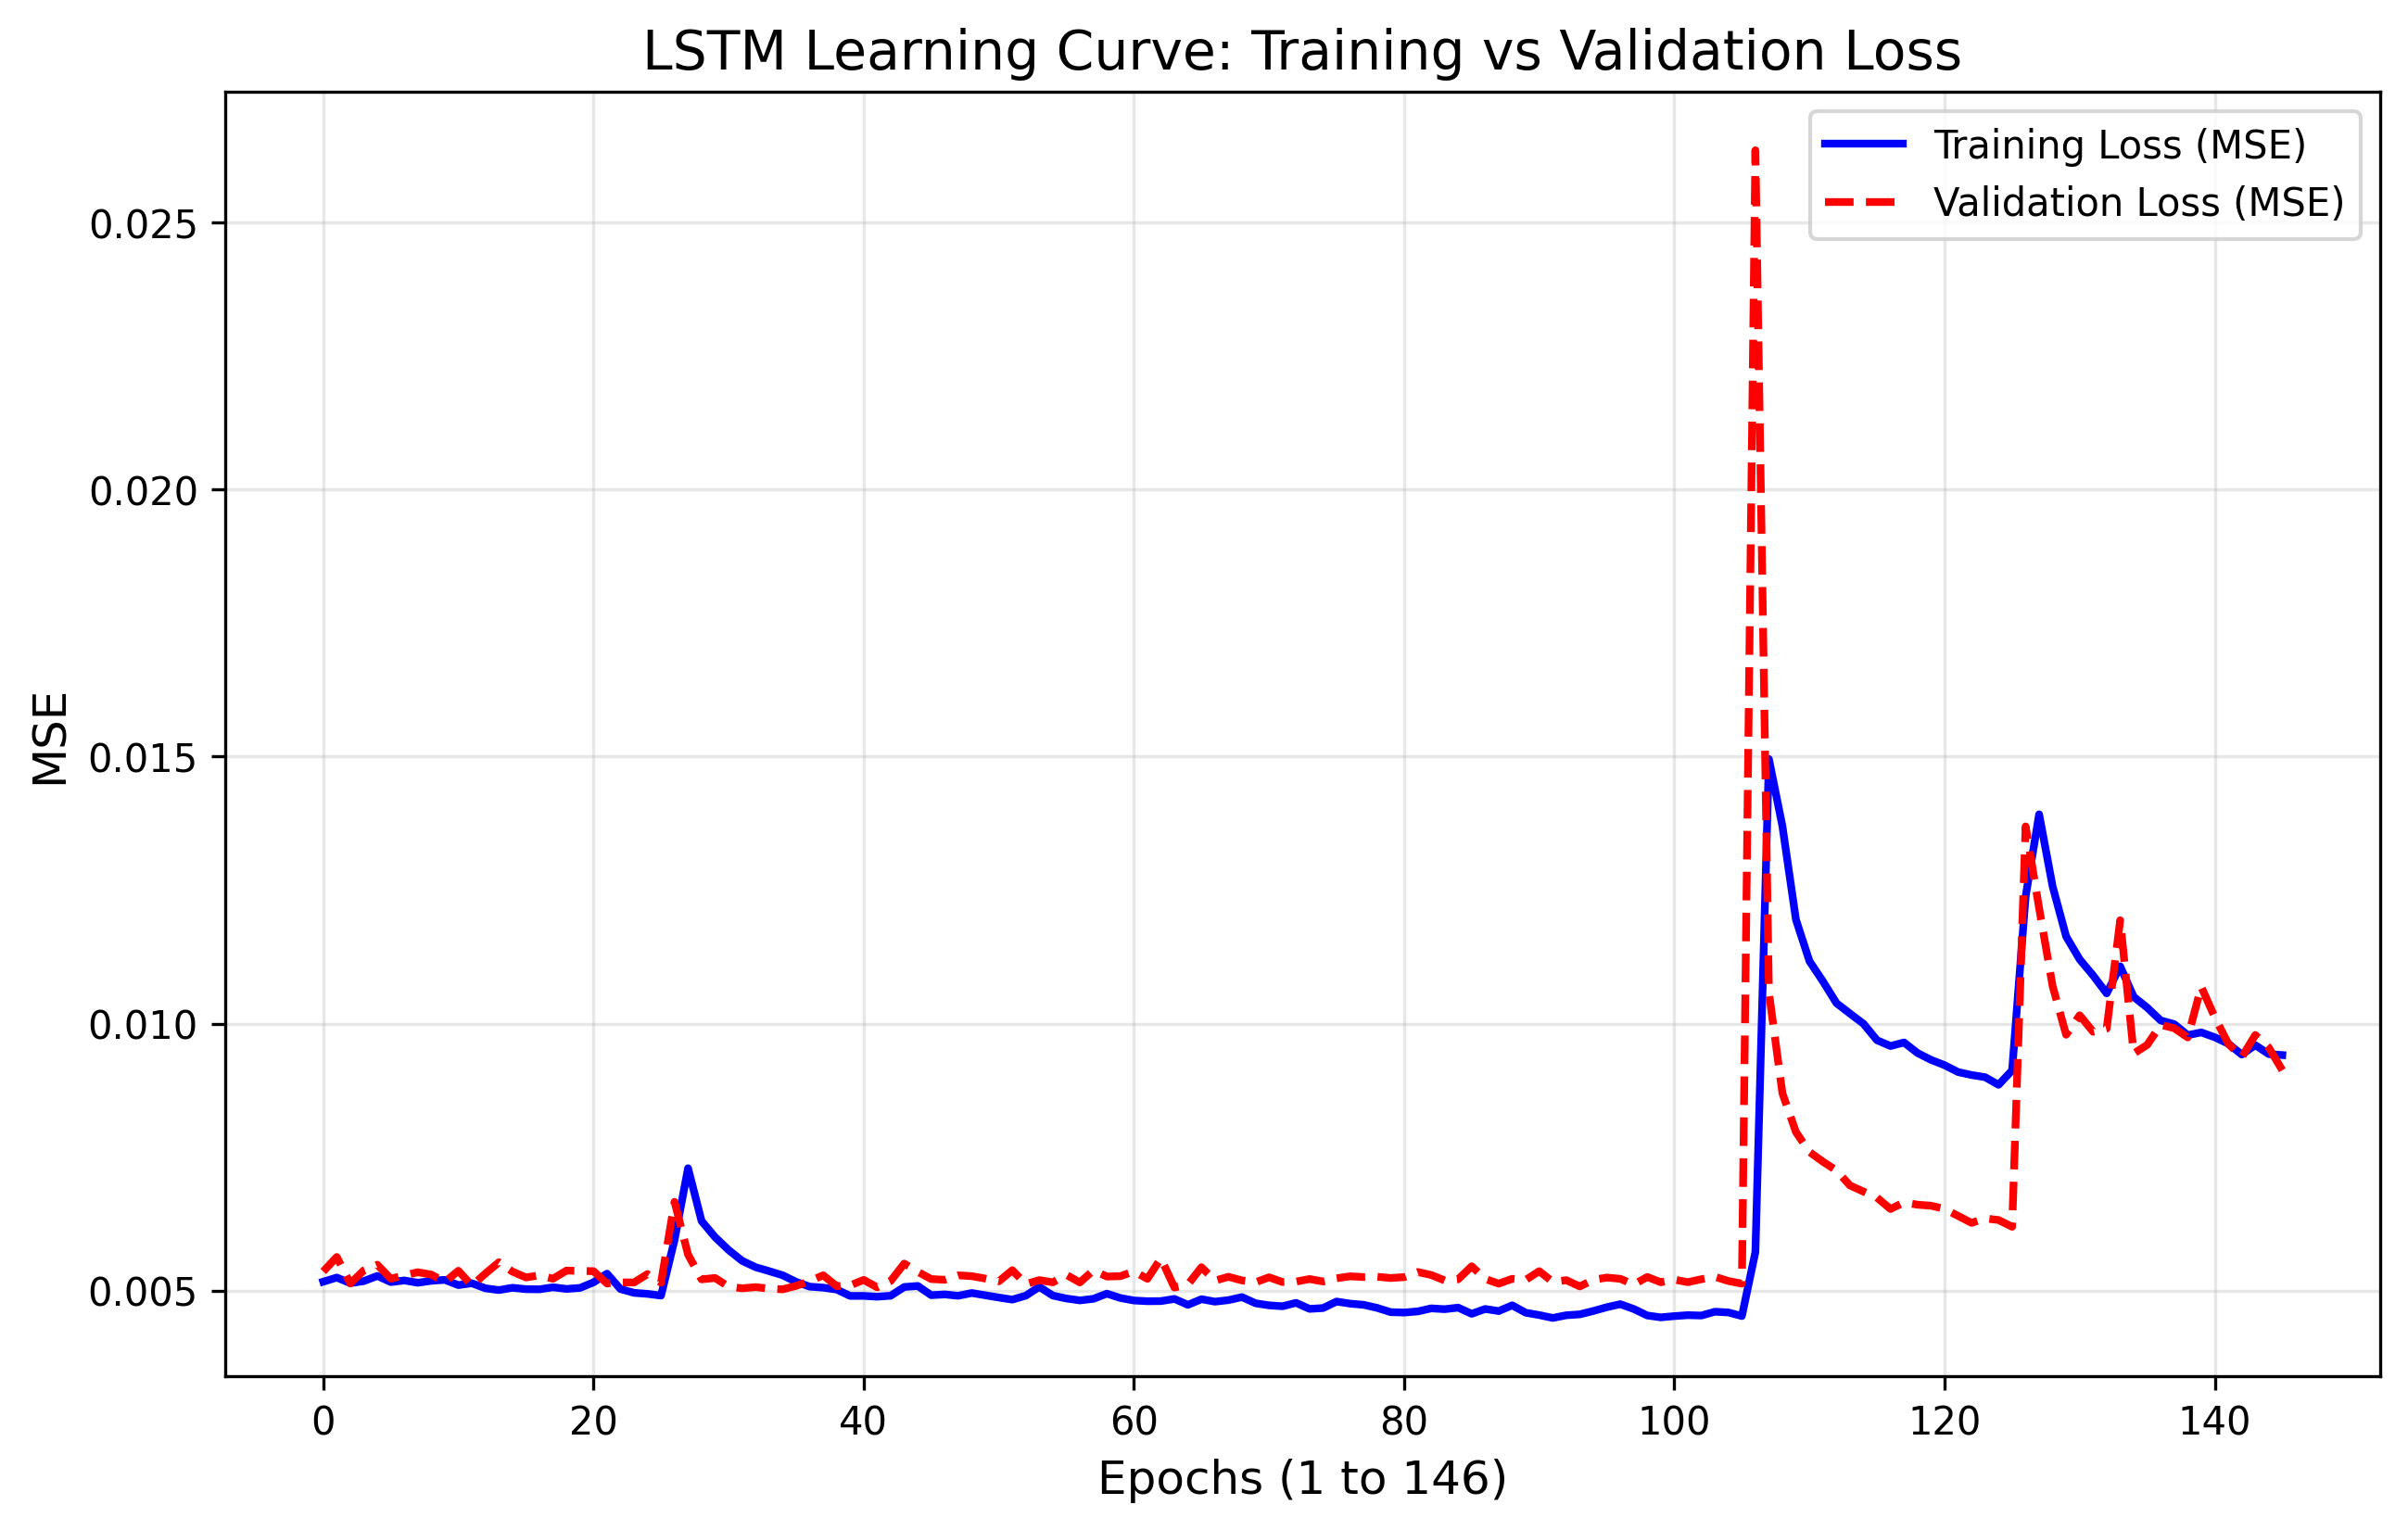

In [11]:
import matplotlib.pyplot as plt

# --- PLOT TRAINING HISTORY ---
plt.figure(figsize=(10, 6), dpi=300)
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='red', linestyle='--', linewidth=2)

plt.title('LSTM Learning Curve: Training vs Validation Loss', fontsize=14)
plt.xlabel('Epochs (1 to 146)', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# Save and Download History Graph
hist_filename = "training_history.png"
plt.savefig(hist_filename, bbox_inches='tight')
files.download(hist_filename)

plt.show()